In [1]:
from pathlib import Path
import pyvcell.vcml as vc
import basico

# Antimony model

In [2]:
antimony_str = """
    // This is a simple example of a spatial model in VCell
    compartment ec = 1;
    compartment cell = 2;
    compartment pm = 1;
    species A in cell;
    species B in cell;
    J0: A -> B; k1*A - k2*B
    J0 in cell;

    k1 = 0.1; k2 = 0.2
    A = 10
"""

import antimony as sb
sbml_str = sb.getSBMLString()

# load into Copasi - not working for me

In [3]:
# sb.writeSBMLFile("antimony.sbml")
# basico.load_model("antimony.sbml")
# basico.get_species()
# basico.get_compartments()

# load into VCell as a Biomodel

In [4]:
biomodel = vc.load_antimony_str(antimony_str)

Found shared library: /Users/jimschaff/Documents/workspace/pyvcell/.venv_jupyter/lib/python3.11/site-packages/libvcell/lib/libvcell.dylib
2025-04-14T02:34:37.163591Z main WARN The use of package scanning to locate Log4j plugins is deprecated.
Please remove the `packages` attribute from your configuration file.
See https://logging.apache.org/log4j/2.x/faq.html#package-scanning for details.
2025-04-13 22:34:37,166 ERROR (SBMLDocument.java:573) - There was an error accessing the sbml online validator!
2025-04-14T02:34:37.171252Z main WARN The Logger cbit.vcell.model.Kinetics was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@5b8ddc79 and is now requested with a null message factory (defaults to org.apache.logging.log4j.message.ParameterizedMessageFactory), which may create log events with unexpected formatting.
2025-04-13 22:34:37,173  WARN (SBMLImporter.java:2878) - failed to transform lumped reaction J0 to distributed: linear factor was null, lu

# correct model

In [5]:
model = biomodel.model
model.get_compartment("pm").dim = 2
display(model)
display(model.parameter_values)

Model(compartments=['ec', 'cell', 'pm'], species=['A', 'B'], reactions=['J0'], parameters=['k1', 'k2'])

{'k1': 0.1, 'k2': 0.2}

# create a 3D geometry

In [6]:
geo = vc.Geometry(name="geo", origin=(0, 0, 0), extent=(10, 10, 10), dim=3)
geo.add_sphere(name="cell_domain", radius=4, center=(5,5,5))
geo.add_background(name="ec_domain")
geo.add_surface(name="pm_domain",sub_volume_1="cell_domain",sub_volume_2="ec_domain")

SurfaceClass(name='pm_domain', subvolume_ref_1='cell_domain', subvolume_ref_2='ec_domain')

# add an application to the biomodel

In [7]:
app = biomodel.add_application("app1", geometry=geo)
app.map_compartment("cell", "cell_domain")
app.map_compartment("ec", "ec_domain")
app.map_species("A", init_conc="sin(x)", diff_coef=1.0)
app.map_species("B", init_conc="cos(x+y+z)", diff_coef=1.0)

sim = app.add_sim(name="sim1", duration=2.0, output_time_step=0.5, mesh_size=(50, 50, 50))

In [8]:
results = vc.simulate(biomodel=biomodel, simulation="sim1")

Found shared library: /Users/jimschaff/Documents/workspace/pyvcell/.venv_jupyter/lib/python3.11/site-packages/libvcell/lib/libvcell.dylib
2025-04-14T02:34:37.200064Z main WARN The use of package scanning to locate Log4j plugins is deprecated.
Please remove the `packages` attribute from your configuration file.
See https://logging.apache.org/log4j/2.x/faq.html#package-scanning for details.
2025-04-14T02:34:37.203916Z main WARN The Logger cbit.vcell.model.Kinetics was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@5dd8f723 and is now requested with a null message factory (defaults to org.apache.logging.log4j.message.ParameterizedMessageFactory), which may create log events with unexpected formatting.
2025-04-14T02:34:37.377818Z main WARN The Logger cbit.vcell.mapping.AbstractMathMapping was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@5dd8f723 and is now requested with a null message factory (defaults t

Simulation Complete in Main() ... 


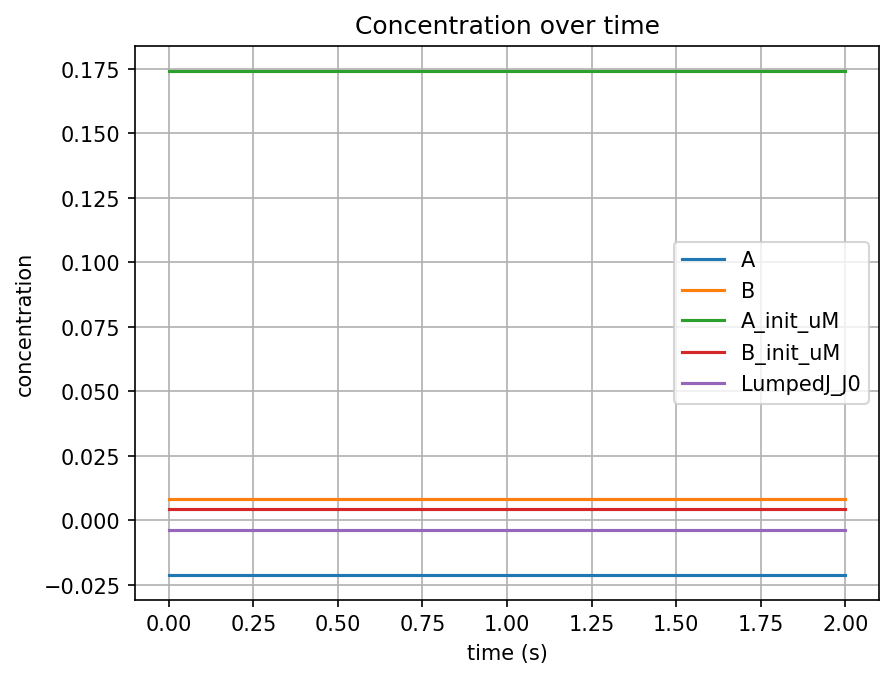

In [9]:
results.plotter.plot_concentrations()

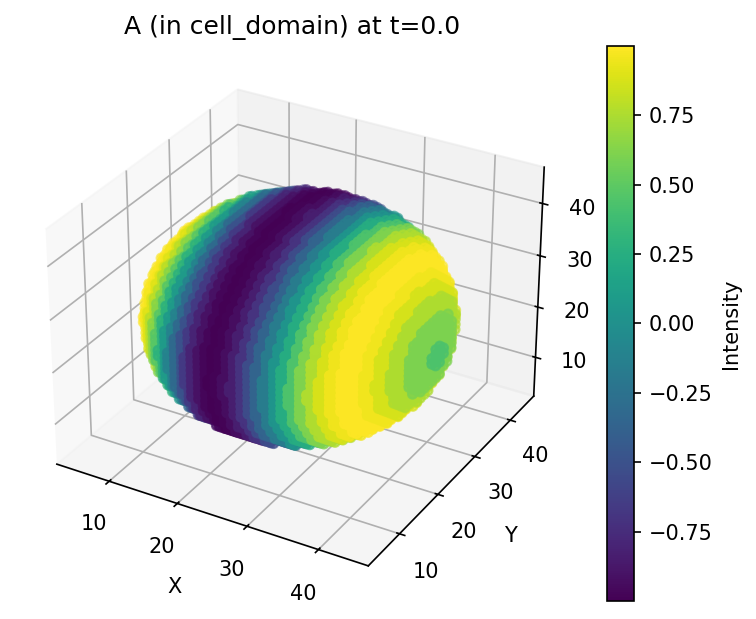

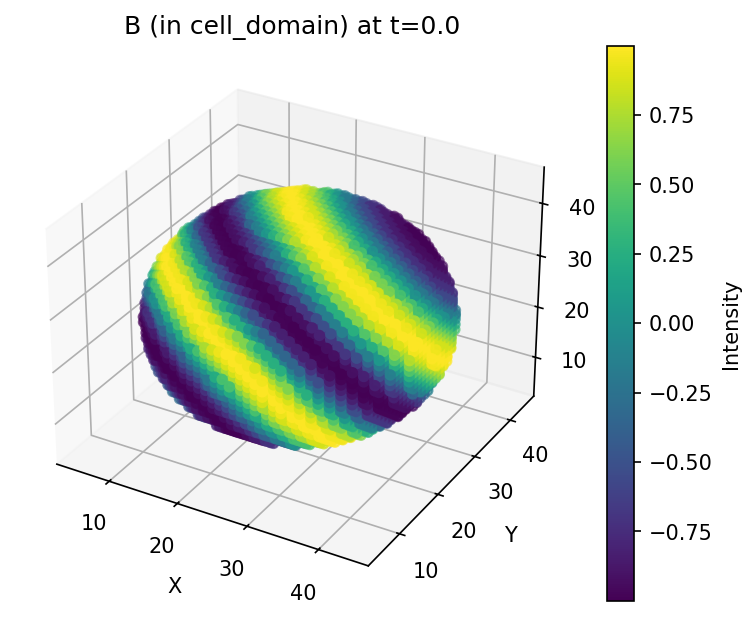

In [10]:
results.plotter.plot_slice_3d(time_index=0,channel_id="A")
results.plotter.plot_slice_3d(time_index=0,channel_id="B")